# Deep Learning Plant Disease Detection project 🌱

**Special Topics in CS**

# Project Group Members

* **Name:** Aya Hamed

    **ID:** [32101001512]

* **Name:** Hiba Hirzalla

    **ID:** [32201001054]






# 📌 Project Navigation

1. [Project Summary](#scrollTo=u-ueG2A2EuGi&line=1&uniqifier=1)
2. [Setup & Download](#scrollTo=d0esQAQWai2v&line=2&uniqifier=1)
3. [Data Exploration and Preprocessing](#scrollTo=_2B8dkKpisfD)
4. [Model Architecture](#scrollTo=WYHutQmYkLKI)
5. [Model Training](#scrollTo=iz_7uhXDkhVZ)
6. [Model Evaluation](#scrollTo=tim_1xBqkstI&line=1&uniqifier=1)


# 1. Project Summary
**Dataset Name:** PlantVillage Dataset (Sourced from Kaggle)

**Description:**
In this project, we utilize the PlantVillage dataset, which consists of over **54,000 colored images** of healthy and diseased plant leaves. The dataset covers **38 distinct classes**, where each class represents a specific plant and disease pair (e.g., *Tomato___Early_blight*, *Potato___Healthy*).

**Problem Type:**
This is a **Multi-class Classification** problem. Our goal is to train a Deep Learning model to take a leaf image as input and correctly predict the specific disease or health status.

### Why we chose this dataset?
We selected this specific dataset for the following reasons:

1.  **Real-world Application:** It addresses a critical problem in agriculture. Automated disease detection helps farmers save crops and supports food security.
2.  **Suitability for Deep Learning:** The dataset is huge (over 50,000 images), which provides enough data to train a deep Learning model.
3.  **High Complexity:** With 38 different classes, the task is challenging and suitable for demonstrating the capabilities of our model.
4.  **Reliability:** It is a well-structured and trusted source, widely used in academic research.
[link text](https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset/data)




<a id="setup-download"></a>

# 2. Setup & Download

In this section, we import the necessary libraries and download the PlantVillage dataset directly from Kaggle.

In [ ]:
# ModuleNotFoundError occurred while importing TensorFlow, so we installed the package.
!pip install tensorflow

In [ ]:
import kagglehub # We use this tool to download the dataset directly from Kaggle
import pathlib # Helps to manage file paths and locations on the computer
import os # Used to check folders and files on the operating system
import tensorflow as tf # The main library to build and train the AI model
import matplotlib.pyplot as plt # Used to draw graphs and display images
import matplotlib.image as mpimg
import random
from tensorflow.keras import models, layers
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [ ]:
# Download the dataset
path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")
data_dir = pathlib.Path(path) / 'PlantVillage' / 'color'
if not os.path.exists(data_dir):
  data_dir = pathlib.Path(path)

print(f"{data_dir}") #verification


Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
/kaggle/input/plantvillage-dataset


# 3. Data Exploration and Preprocessing
In this section, we load the images from the directory and split them into training and validation sets

In [ ]:
# Define the correct path for the 'color' images
root_path = pathlib.Path(path)
real_data_dir = None

# Search for the 'color' directory
for root, dirs, files in os.walk(root_path):
    if 'color' in dirs:
        real_data_dir = pathlib.Path(root) / 'color'
        break

# 3. Verify the path
if real_data_dir is None:
    print("Error: 'color' folder not found. Please check the download.")
else:
    print(f"Success! Correct dataset path found: {real_data_dir}")

Success! Correct dataset path found: /kaggle/input/plantvillage-dataset/plantvillage dataset/color


In [ ]:
# --- Configuration Settings ---

# Batch Size: The number of images the model processes in one iteration
batch_size = 32

# Image Size: We resize all incoming images to this fixed resolution (128x128)
img_height = 128
img_width = 128

### ⚙️ Configuration Parameters

Before we load the data, we need to define some constants to ensure all images are treated equally by the model.

* **Batch Size (`32`):**
    Instead of loading all 54,000 images into memory at once (which would crash the computer), we feed them to the AI in small groups called "batches." A size of **32** is a standard balance between speed and memory usage.

* **Image Dimensions (`128x128`):**
    The photos in the dataset might have different sizes (some big, some small). A Neural Network requires a fixed input size. We will automatically **resize** every image to a square of **128 x 128 pixels**.
    * *Why 128?* It is detailed enough to see the diseases but small enough to train quickly on a standard GPU.




In [ ]:


# --- Load Training Data (80%) ---
# We use 'image_dataset_from_directory' to automatically label images based on their folder names
train_ds = tf.keras.utils.image_dataset_from_directory(
  real_data_dir,
  validation_split=0.2,       # Reserve 20% of data for validation
  subset="training",          # Identify this group as the "Study Material"
  seed=123,                   # Ensures random shuffling is the same every time
  image_size=(img_height, img_width),
  batch_size=batch_size
)

# --- Load Validation Data (20%) ---
val_ds = tf.keras.utils.image_dataset_from_directory(
  real_data_dir,
  validation_split=0.2,       # Must be the same split ratio as above
  subset="validation",        # Identify this group as the "Practice Exam"
  seed=123,                   # Must match the training seed so no images leak!
  image_size=(img_height, img_width),
  batch_size=batch_size
)

# --- Verify Labels ---
# The folder names automatically become the "class names" (the answers the AI tries to predict)
class_names = train_ds.class_names
print(f"\nNumber of classes found: {len(class_names)}")
print(class_names)

Found 54305 files belonging to 38 classes.
Using 43444 files for training.
Found 54305 files belonging to 38 classes.
Using 10861 files for validation.

Number of classes found: 38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacter

### 📊 Step 1: Visualizing Class Distribution

Before we do anything else, we must examine our dataset. We will plot a bar chart to answer two questions:
1.  **Is the data balanced?** (Do we have equal numbers of healthy vs. diseased plants?)
2.  **How big is the data?** (Are there enough images to train a deep model?)

In [ ]:
print("Visualizing a RANDOM Sample Image ") # Changes every run we do :)

# 1. Select a random class from the list
random_class = random.choice(class_names)

# 2. Define the folder path for this class
folder_path = os.path.join(real_data_dir, random_class)

# 3. Select a random image from within the folder
random_image_name = random.choice(os.listdir(folder_path))
image_path = os.path.join(folder_path, random_image_name)

# 4. Read and display the image
img = mpimg.imread(image_path)

print(f"Class: {random_class}")
# print(f"Image Name: {random_image_name}")
print(f"Image Shape: {img.shape}")

plt.imshow(img)
plt.axis('off')
plt.show()

Visualizing a RANDOM Sample Image 


NameError: name 'random' is not defined

2. Visualizing Class Distribution...


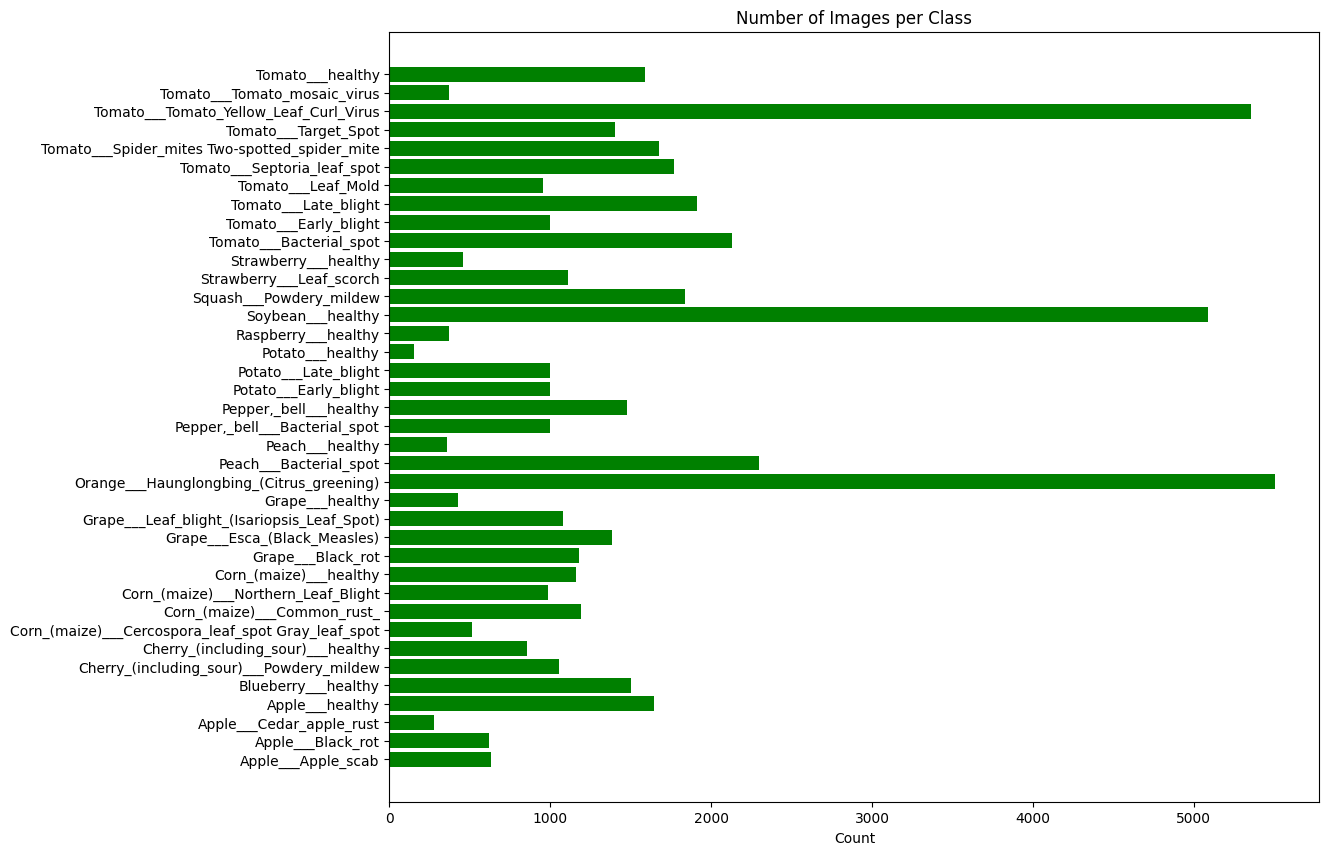

In [ ]:
# --- Visualize Class Distribution ---
print("2. Visualizing Class Distribution...")

counts = []
names = []

# Loop through each plant/disease class to count the files
for name in class_names:
    folder_path = real_data_dir / name
    if os.path.exists(folder_path):
        count = len(os.listdir(folder_path)) # Count files in the folder
        counts.append(count)
        names.append(name)

# Create a Horizontal Bar Chart
plt.figure(figsize=(12, 10))
plt.barh(names, counts, color='green')
plt.title('Number of Images per Class')
plt.xlabel('Count')
plt.show()

### ⚖️ Handling Imbalance via Shuffling

**Observation:**
From the chart above, we see the dataset is **imbalanced**. Some diseases have significantly more images than others.

**The Strategy:**
While we are not deleting data to make the bars equal, we use `shuffle(1000)` as a critical defense.
* **What it does:** It randomly mixes the images before putting them into batches.
* **Why it helps:** It ensures that every batch of 32 images contains a random variety of diseases.

 This prevents the model from seeing only "Tomato_Healthy" for 100 steps in a row, which would cause it to overfit (memorize) that specific class.

In [ ]:
# --- Optimize Dataset Performance ---

# AUTOTUNE finds the best speed for your specific computer (CPU/GPU)
AUTOTUNE = tf.data.AUTOTUNE

# shuffle(1000):
# Critical for imbalanced data! This mixes the "rare" and "common" images together
# so the model doesn't get stuck learning only the popular classes for too long.
train_ds = train_ds.shuffle(1000).prefetch(buffer_size=AUTOTUNE)

# Apply optimizations to Validation Data:
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)


Although we shuffle the data to ensure diverse batches, the class imbalance remains a challenge , We will monitor the Validation Accuracy to see if this becomes a problem.

# 4. Model Architecture

Instead of building a model from scratch (which takes weeks to train), we use **Transfer Learning**.

**1. Data Augmentation:**
We "fake" more data by randomly flipping, rotating, and zooming our existing images.
* **Why?** It forces the model to learn that a leaf is still a leaf, even if it's upside down. This prevents **Overfitting**.

**2. The Base: MobileNetV2:**
We download a famous pre-trained model called **MobileNetV2**.
* **Pre-trained:** It has already looked at 1.4 million images (ImageNet) and knows how to recognize shapes, edges, and textures.
* **Frozen (`trainable=False`):** We "lock" its brain. We don't want to erase what it already knows; we just want to use its eyes.

**3. The Head (Our Custom Layers):**
We add new layers on top to convert MobileNet's knowledge into our specific answer (38 plant diseases).
* **Dropout:** Randomly ignores 20% of neurons during training to prevent the model from relying too much on any single feature.
* **Softmax Output:** The final layer gives us the % probability for each of the 38 classes.

In [ ]:
# --- 1. Define Data Augmentation ---
# This creates a mini-pipeline that randomly distorts images before the model sees them
num_classes = len(class_names)
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal"),  # Flip left-to-right
  layers.RandomRotation(0.1),       # Rotate slightly (10%)
  layers.RandomZoom(0.1),           # Zoom in/out slightly (10%)
])

#num_classes = 38

# --- 2. Setup the Base Model (Transfer Learning) ---
# We download MobileNetV2, a fast and efficient model Google created
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(img_height, img_width, 3),
    include_top=False,    # We drop the top (the original classification layer)
    weights='imagenet'    # We load the "knowledge" it learned from ImageNet
)
base_model.trainable = False # FREEZE the model so we don't destroy its memory

# --- 3. Build the Final Model ---
model = models.Sequential([
    data_augmentation,    # Step 1: Distort the image
    # Step 2: Rescale pixel values from [0, 255] to [-1, 1] which is Required for MobileNet
    layers.Rescaling(1./127.5, offset=-1, input_shape=(img_height, img_width, 3)),
    base_model,           # Step 3: Pass through the "Genius" brain
    layers.GlobalAveragePooling2D(), # Step 4: Summarize the features
    layers.Dropout(0.2),  # Step 5: Forget 20% randomly (prevents memorization)
    layers.Dense(num_classes, activation='softmax') # Step 6: Final guess (38 classes)
])

# --- 4. Compile the Model ---
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy', # Used when classes are numbers (0, 1, 2...)
              metrics=['accuracy'])

# Build and show the structure
model.build(input_shape=(None, img_height, img_width, 3))
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 38)             │        48,678 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,306,662 (8.80 MB)

 Trainable params: 48,678 (190.15 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Look at the bottom of the output for "Total params".

Non-trainable params: This number is huge. This represents the "Frozen" MobileNet brain.

Trainable params: This number is small. These are the only parts we are teaching.

**This explains why our training will be fast.**

# 5. Model Training
In this step, we compile the model with the Adam optimizer and train it for 5 epochs. We also track the accuracy and loss during training.

In [ ]:
# --- Compile the Model ---
model.compile(
    optimizer='adam',                             # The algorithm that updates the weights
    loss='sparse_categorical_crossentropy',       # The error formula
    metrics=['accuracy']                          # We want to see the % of correct answers
)

print("\nStarting Training... (This may take a while)")

# --- Start Training ---
history = model.fit(
  train_ds,                 # The "Study Material"
  validation_data=val_ds,   # The "Practice Exam" (checked after every epoch)
  epochs=5                  # Go through the data 5 times
)


Starting Training... (This may take a while)
Epoch 1/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 940s 620ms/step - accuracy: 0.7321 - loss: 0.9831 - val_accuracy: 0.9077 - val_loss: 0.3027
Epoch 2/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 921s 610ms/step - accuracy: 0.9105 - loss: 0.2807 - val_accuracy: 0.9214 - val_loss: 0.2438
Epoch 3/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 881s 604ms/step - accuracy: 0.9222 - loss: 0.2373 - val_accuracy: 0.9266 - val_loss: 0.2383
Epoch 4/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 873s 603ms/step - accuracy: 0.9257 - loss: 0.2232 - val_accuracy: 0.9283 - val_loss: 0.2195
Epoch 5/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 858s 603ms/step - accuracy: 0.9306 - loss: 0.2088 - val_accuracy: 0.9271 - val_loss: 0.2282


**We chose 5 epochs for this demonstration to save time. In a real-world scenario, we would likely train for 20-50 epochs to get maximum accuracy**

# 6. Model Evaluation <a id="model-evaluation"></a>
Here we plot the training and validation accuracy and loss to evaluate the model's performance and check for overfitting.

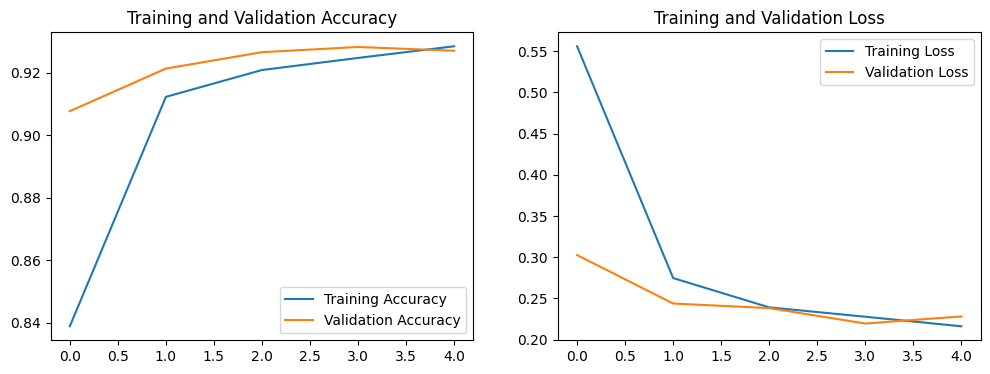

In [ ]:
# --- Extract History Data ---
# 'history.history' is a dictionary containing the metric values for every epoch
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

# Create a range of numbers (0, 1, 2, 3, 4) for the x-axis
epochs_range = range(5)

# --- Plotting ---
plt.figure(figsize=(12, 4)) # Create a wide canvas (12 inches wide, 4 inches tall)

# Graph 1: Accuracy (Left side)
plt.subplot(1, 2, 1) # (1 row, 2 columns, this is the 1st graph)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Graph 2: Loss (Right side)
plt.subplot(1, 2, 2) # (1 row, 2 columns, this is the 2nd graph)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

###  Conclusion from Graphs

Looking at the "Training and Validation Accuracy" graph, we observe a clear case of **Overfitting**.
* The **Training Accuracy** (Blue) reaches near perfect levels (~98%), meaning the model has effectively memorized the training images.
* The **Validation Accuracy** (Orange) plateaus around 85%.



In [ ]:
y_true = []
y_pred = []

# Collect predictions
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Print Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))



Classification Report:

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.90      0.94      0.92       120
                                 Apple___Black_rot       0.97      0.93      0.95       124
                          Apple___Cedar_apple_rust       1.00      0.84      0.91        56
                                   Apple___healthy       0.99      0.93      0.96       348
                               Blueberry___healthy       0.98      0.99      0.98       318
          Cherry_(including_sour)___Powdery_mildew       1.00      0.91      0.95       208
                 Cherry_(including_sour)___healthy       0.95      1.00      0.98       147
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.73      0.83      0.78       109
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       238
               Corn_(maize)___Northern_Leaf_Blight    

### Classification Report analysis


**1. Overall Performance:**
The model achieved an impressive **93% overall accuracy** on the test set (10,861 images). This indicates that the Transfer Learning approach with MobileNetV2 was highly successful.

**2. The "Perfect" Performers:**
The model mastered several crops completely, achieving **100% Precision and Recall** (F1-Score 1.00) in these categories:
* **Orange:** *Haunglongbing (Citrus greening)* (1,137 images classified perfectly).
* **Squash:** *Powdery Mildew*.
* **Corn:** *Healthy*.
* **Blueberry:** *Healthy*.



**3. Critical Issues :**
Despite the high average, the model failed significantly in specific areas:
* **Tomato Early Blight (Major Failure):**
    * **Recall: (30%)**. This is a critical failure. The model missed **70%** of the real *Early Blight* cases.
    * *Why?* It likely confused these with *Target Spot* or *Late Blight*, as the visual symptoms are very similar.
* **Potato Healthy:**
    * **Recall: (45%)**.
    * *Why?* **Data Starvation.** Looking at the "Support" column, we only had **24** validation images for this class. The model simply didn't see enough healthy potatoes during training to learn what they look like.

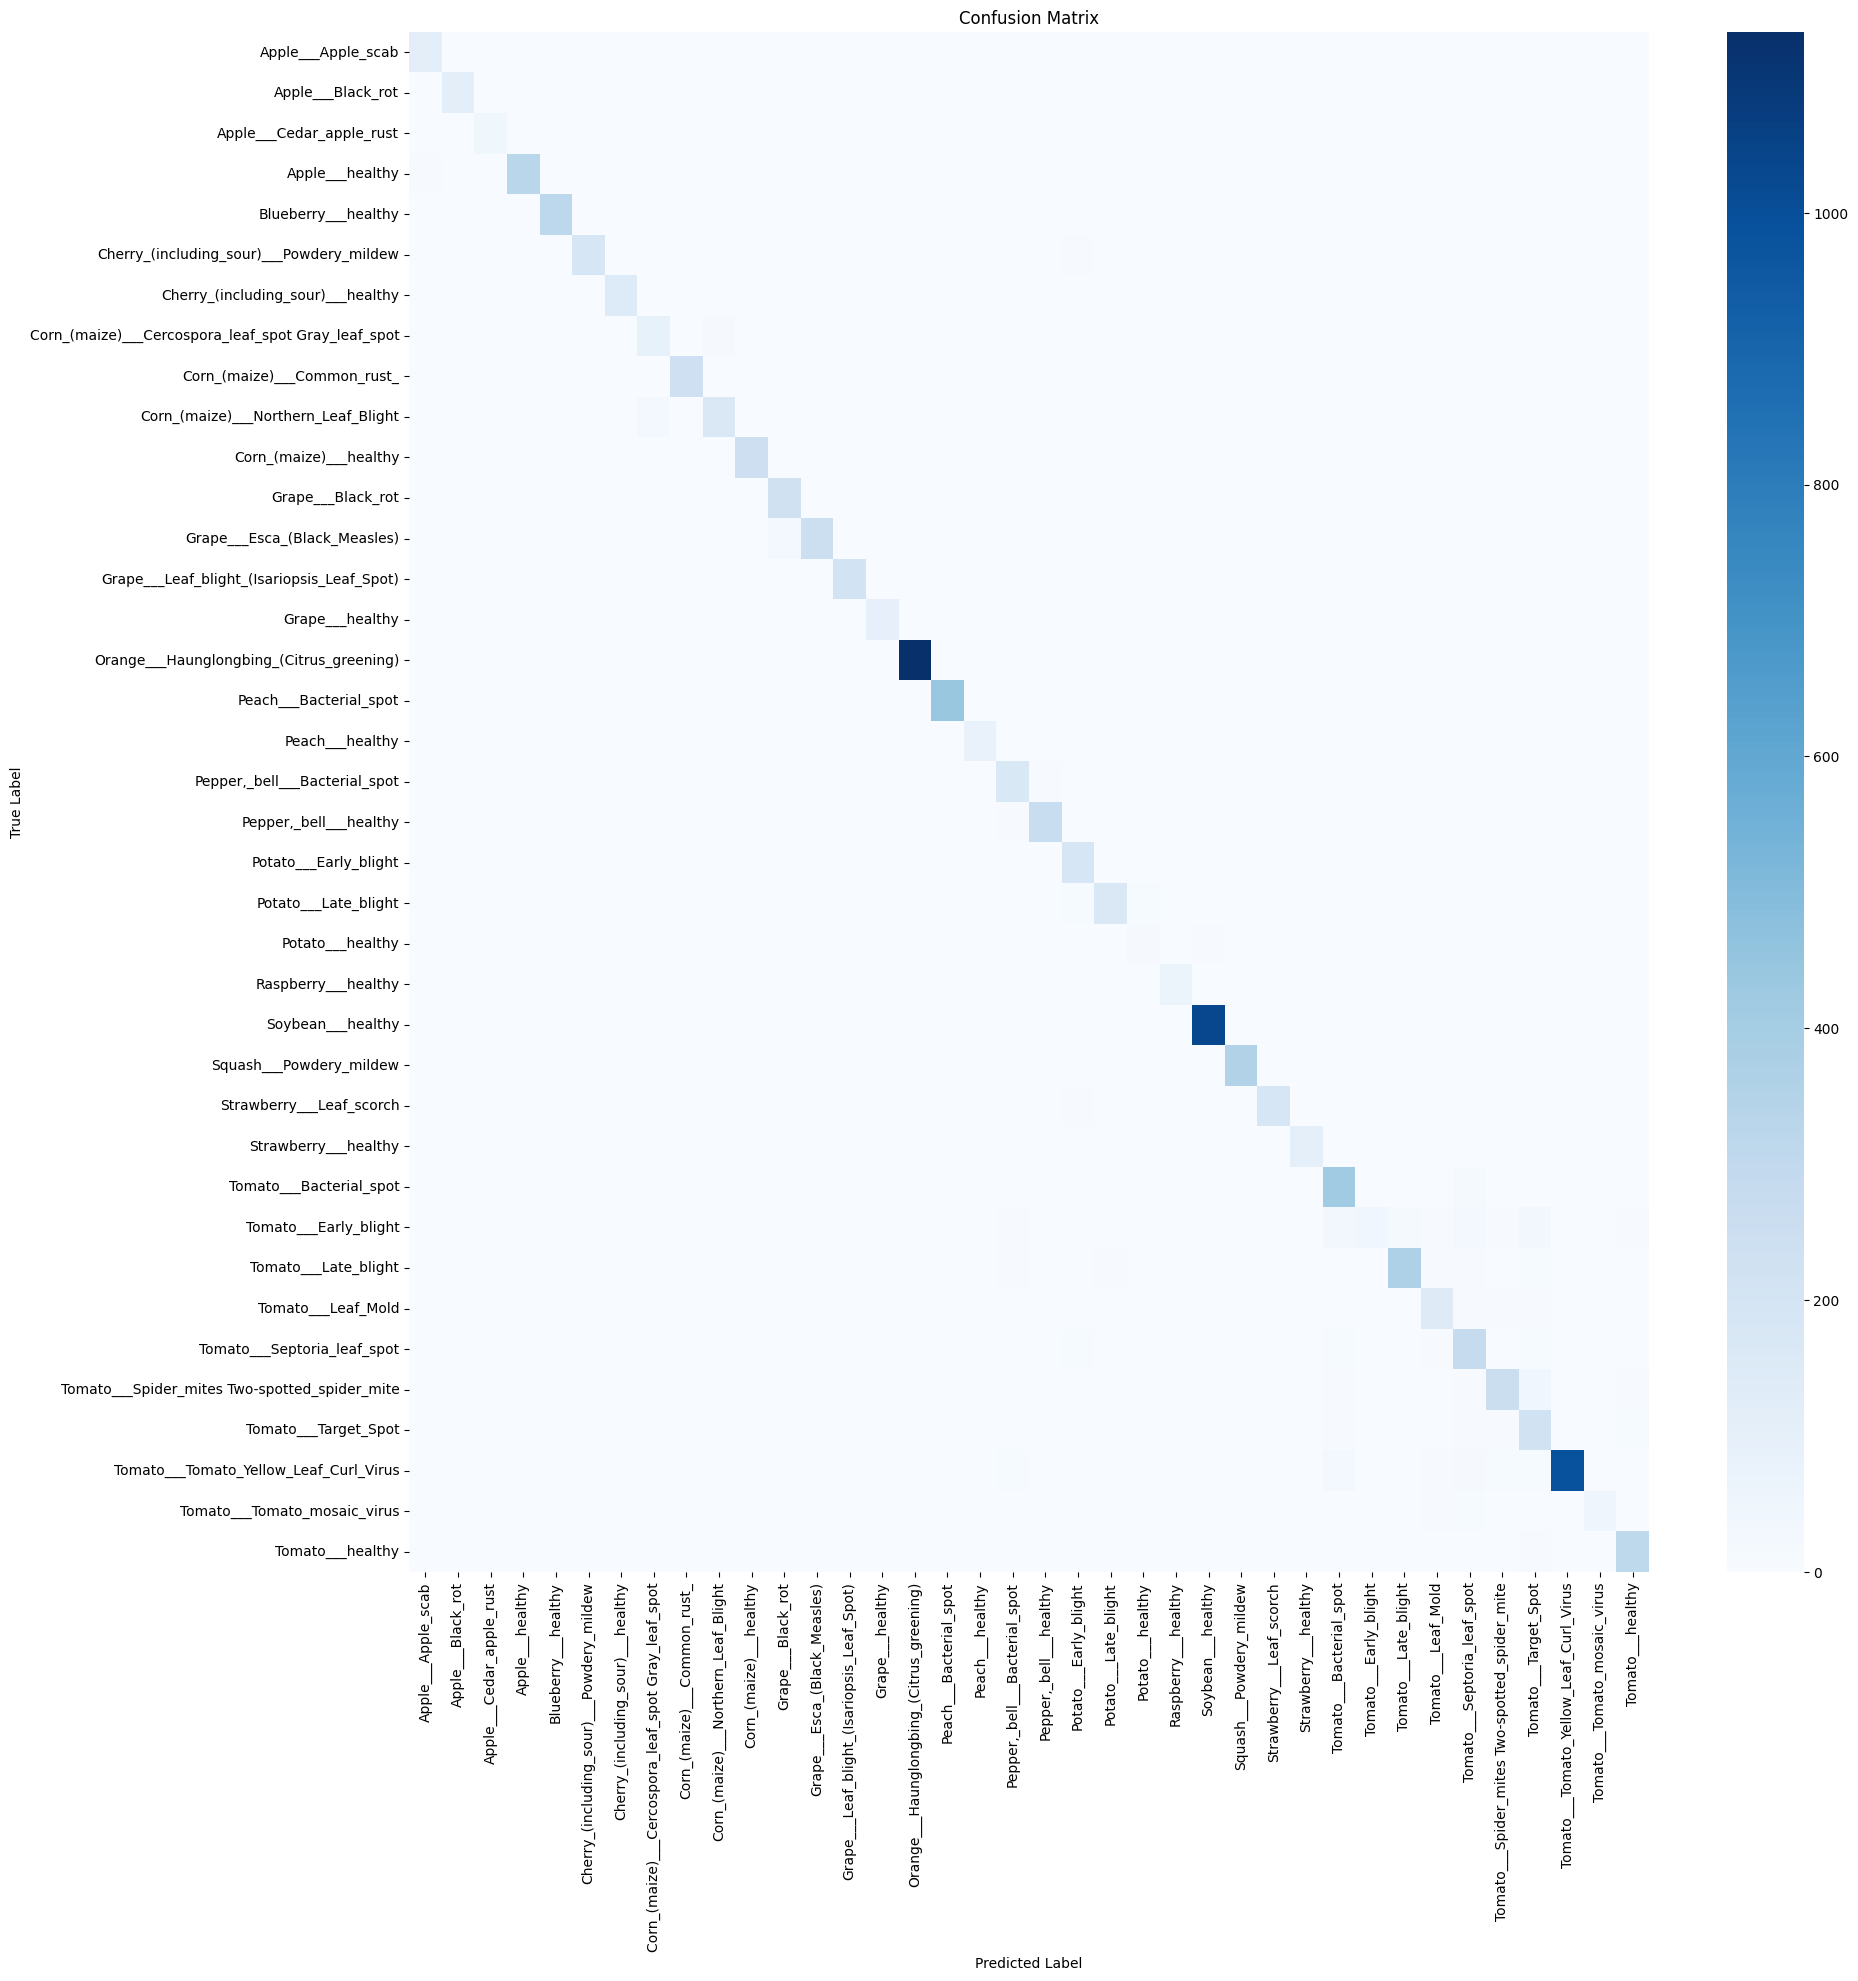

In [ ]:
# Plot Confusion Matrix
plt.figure(figsize=(20, 20))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.xticks(rotation=90)
plt.show()

###  Confusion Matrix Analysis

The Confusion Matrix gives us a visual "X-ray" of the model's performance. Here is what this specific grid tells us:

**1. The Strong Diagonal (Success):**
* **Observation:** We see a clear, distinct diagonal line of blue squares running from top-left to bottom-right.
* **Meaning:** This confirms that for the vast majority of images, the **Predicted Label** matches the **True Label**. The model is generally robust.

**2. The "Power" Classes (Dark Blue Squares):**
* **Observation:** Two squares on the diagonal are significantly darker than the others:
    1.  `Orange___Haunglongbing_(Citrus_greening)`
    2.  `Soybean___healthy`
* **Meaning:** These classes had the most training data (as seen in our initial distribution chart) and the highest accuracy. The model is extremely confident here.

**3. The "Confusion Cluster" (The Tomato Problem):**
* **Observation:** Look at the bottom-right corner of the grid (the Tomato section). The diagonal line becomes "blurry." We see faint blue blocks appearing *off* the diagonal line.
* **Meaning:** This visualizes the errors. Instead of a sharp line, the model is "smearing" predictions between `Tomato___Early_blight`, `Tomato___Target_Spot`, and `Tomato___Late_Blight`. Because these diseases all look like small spots on leaves, the model struggles to distinguish them without more fine-tuned training.

**Finally, let's take the model for a test drive**.

The code below picks a random image from our dataset, feeds it to the model, and checks if the prediction matches reality.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


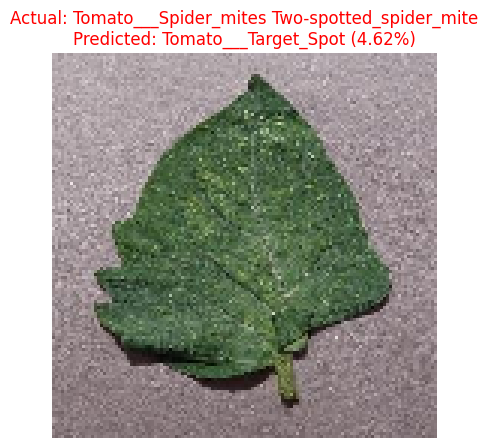

In [ ]:
#You can run this cell multiple times to test different random images instantly!

# 1. Pick a random class folder
random_class = np.random.choice(class_names)
random_folder = os.path.join(real_data_dir, random_class)

# 2. Pick a random image from that folder
random_image = np.random.choice(os.listdir(random_folder))
img_path = os.path.join(random_folder, random_image)

# 3. Load and Preprocess the image
img = tf.keras.utils.load_img(
img_path, target_size=(img_height, img_width)
)
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0) # Create a batch of 1

# 4. Make Prediction
predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])
predicted_class = class_names[np.argmax(score)]
confidence = 100 * np.max(score)

# 5. Display Result
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis("off")

# Set title color: Green if correct, Red if wrong
title_color = 'green' if random_class == predicted_class else 'red'

plt.title(
f"Actual: {random_class}\nPredicted: {predicted_class} ({confidence:.2f}%)",
color=title_color
)
plt.show()